# 🚗 DrowsyDriver AI — Báo cáo Đánh giá Mô hình

**Dự án:** IS54A — Hệ thống phát hiện buồn ngủ khi lái xe  
**Stack:** Android · CameraX · MediaPipe FaceLandmarker · TensorFlow Lite  

---

## Kiến trúc hệ thống

```
Camera Frame
    ↓
MediaPipe FaceLandmarker (478 landmarks)
    ├── Tính EAR (Eye Aspect Ratio)  ─────────────────────┐
    ├── Tính MAR (Mouth Aspect Ratio) ─────────────────────┤
    ├── Crop vùng mắt   → CNN Eye  (drowsiness_model)      ├──→ DrowsinessAnalyzer
    └── Crop vùng miệng → CNN Yawn (yawn_cbam)             ┘         ↓
                                                             AlertController + GPS
```

## Models trong `app/src/main/assets/`

| File | KB | Mục đích |
|------|----|----------|
| `drowsiness_model.tflite` | 46 | CNN Eye: eyes_closed / eyes_open |
| `yawn_cbam.tflite` | 131 | CNN Yawn (CBAM): yawn / no_yawn |
| `temporal_model.tflite` | 42 | Temporal sequence model |
| `face_landmarker.task` | 3671 | MediaPipe 478 facial landmarks |

In [1]:
# ── CELL 1: SETUP ──────────────────────────────────────────────────────
import asyncio, os, sys, warnings, random

# Fix zmq/asyncio warning trên Windows
if sys.platform == 'win32':
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import cv2

import matplotlib
# Tự động chọn backend phù hợp
try:
    get_ipython()                          # chạy trong Jupyter/VS Code
    matplotlib.use('module://matplotlib_inline.backend_inline')
    from IPython import display
    IN_NOTEBOOK = True
except Exception:
    matplotlib.use('Agg')                  # chạy qua nbconvert
    IN_NOTEBOOK = False

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support
)

# TFLite loader
try:
    import tensorflow as tf
    _TF_VER = tf.__version__
    def _load(p): i = tf.lite.Interpreter(model_path=str(p)); i.allocate_tensors(); return i
except ImportError:
    import tflite_runtime.interpreter as _tfl
    _TF_VER = 'tflite_runtime'
    def _load(p): i = _tfl.Interpreter(model_path=str(p)); i.allocate_tensors(); return i

PROJECT_ROOT = Path('.').resolve()
ASSETS       = PROJECT_ROOT / 'app' / 'src' / 'main' / 'assets'
OUTPUTS      = PROJECT_ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

print(f'✅  Setup OK')
print(f'   Project : {PROJECT_ROOT.name}')
print(f'   TF/TFLite: {_TF_VER}')
print(f'   OpenCV  : {cv2.__version__}')
import sklearn; print(f'   sklearn : {sklearn.__version__}')

✅  Setup OK
   Project : DrowsyDriverAndroid
   TF/TFLite: 2.21.0
   OpenCV  : 4.13.0
   sklearn : 1.9.0


  DATASET    SPLIT        class[0]     class[1]    TOTAL
  --------------------------------------------------------
  cnn_eye    train          25,167       25,770   50,937
  cnn_eye    val             8,389        8,591   16,980
  cnn_eye    test            8,390        8,591   16,981

  cnn_yawn   train           2,072        2,022    4,094
  cnn_yawn   val               259          252      511
  cnn_yawn   test              260          254      514



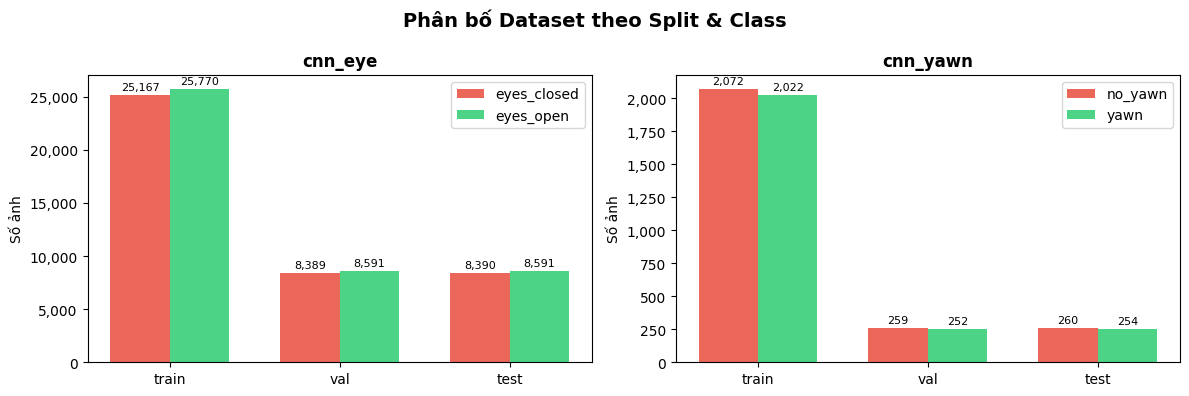

✅  outputs/dataset_overview.png


In [2]:
# ── CELL 2: TỔNG QUAN DATASET ──────────────────────────────────────────
DATASETS = {
    'cnn_eye':  {'root': PROJECT_ROOT / 'dataset',      'classes': ['eyes_closed', 'eyes_open']},
    'cnn_yawn': {'root': PROJECT_ROOT / 'dataset_yawn', 'classes': ['no_yawn', 'yawn']},
}

all_counts = {}
for ds, cfg in DATASETS.items():
    counts = {}
    for split in ['train', 'val', 'test']:
        counts[split] = {}
        for cls in cfg['classes']:
            d = cfg['root'] / split / cls
            n = len([p for p in d.iterdir() if p.suffix.lower() in IMG_EXTS]) if d.exists() else 0
            counts[split][cls] = n
    all_counts[ds] = counts

# In bảng
print(f'  {"DATASET":<10} {"SPLIT":<8} {"class[0]":>12} {"class[1]":>12} {"TOTAL":>8}')
print('  ' + '-'*56)
for ds, counts in all_counts.items():
    classes = DATASETS[ds]['classes']
    for split in ['train', 'val', 'test']:
        c0 = counts[split][classes[0]]
        c1 = counts[split][classes[1]]
        print(f'  {ds:<10} {split:<8} {c0:>12,} {c1:>12,} {c0+c1:>8,}')
    print()

# Biểu đồ cột
COLORS = ['#E74C3C', '#2ECC71', '#3498DB', '#E67E22']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Phân bố Dataset theo Split & Class', fontsize=14, fontweight='bold')
for ax, (ds, counts) in zip(axes, all_counts.items()):
    classes = DATASETS[ds]['classes']
    splits  = ['train', 'val', 'test']
    x, w = np.arange(len(splits)), 0.35
    for i, cls in enumerate(classes):
        vals = [counts[s][cls] for s in splits]
        bars = ax.bar(x + i*w - w/2, vals, w, label=cls, color=COLORS[i], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                    f'{v:,}', ha='center', va='bottom', fontsize=8)
    ax.set_title(ds, fontweight='bold'); ax.set_xticks(x); ax.set_xticklabels(splits)
    ax.legend(); ax.set_ylabel('Số ảnh')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v):,}'))
plt.tight_layout()
plt.savefig(OUTPUTS / 'dataset_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅  outputs/dataset_overview.png')

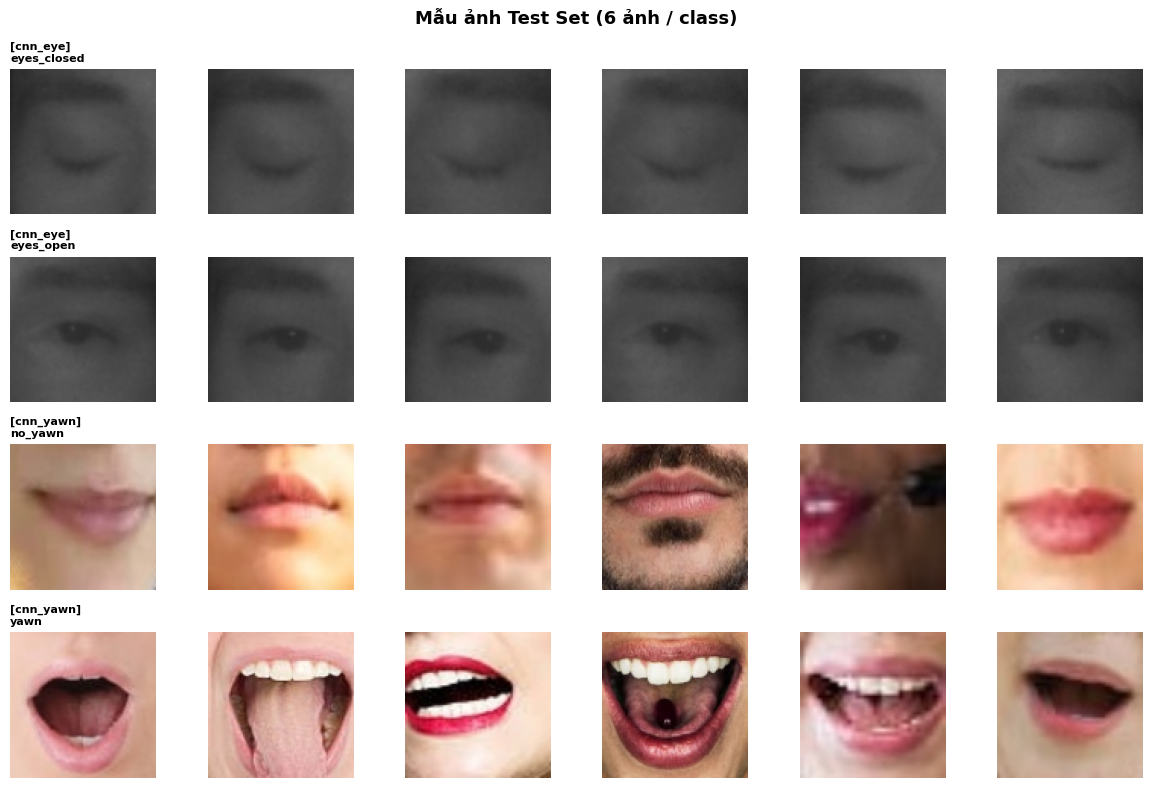

✅  outputs/sample_images.png


In [3]:
# ── CELL 3: HIỂN THỊ MẪU ẢNH ──────────────────────────────────────────
def read_img_rgb(path, size=96):
    raw = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(raw, cv2.IMREAD_COLOR)
    if img is None: return None
    return cv2.cvtColor(cv2.resize(img, (size, size)), cv2.COLOR_BGR2RGB)

N = 6
fig, axes = plt.subplots(4, N, figsize=(N*2, 4*2))
fig.suptitle('Mẫu ảnh Test Set (6 ảnh / class)', fontsize=13, fontweight='bold')
row = 0
for ds, cfg in DATASETS.items():
    for cls in cfg['classes']:
        imgs = sorted([p for p in (cfg['root']/'test'/cls).iterdir() if p.suffix.lower() in IMG_EXTS])[:N]
        for col, p in enumerate(imgs):
            ax = axes[row][col]
            im = read_img_rgb(p)
            if im is not None: ax.imshow(im)
            ax.axis('off')
            if col == 0: ax.set_title(f'[{ds}]\n{cls}', fontsize=8, fontweight='bold', loc='left')
        row += 1
plt.tight_layout()
plt.savefig(OUTPUTS / 'sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅  outputs/sample_images.png')

In [4]:
# ── CELL 4: LOAD TFLITE MODELS ─────────────────────────────────────────
# Preprocessing giống hệt Android (TfliteDrowsinessClassifier.kt)
#   R = ((pixel >> 16) & 0xFF) / 255f
#   G = ((pixel >>  8) & 0xFF) / 255f
#   B = ( pixel        & 0xFF) / 255f

def preprocess(path, size=64):
    raw = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(raw, cv2.IMREAD_COLOR)
    if img is None: return None
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_CUBIC)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)    # Android: ARGB → R G B
    return (img.astype(np.float32) / 255.0)[np.newaxis]  # /255 NGOÀI model!

def infer(interp, tensor):
    inp = interp.get_input_details()[0]
    out = interp.get_output_details()[0]
    interp.set_tensor(inp['index'], tensor)
    interp.invoke()
    return interp.get_tensor(out['index'])[0]

MODELS = {
    'cnn_eye': {
        'path':      ASSETS / 'drowsiness_model.tflite',
        'test_dir':  PROJECT_ROOT / 'dataset' / 'test',
        'classes':   ['eyes_closed', 'eyes_open'],
        'pos_cls':   'eyes_closed',
        'threshold': 0.55,          # CNN_CONF_THRESHOLD (Constants.kt)
        'color':     ['#E74C3C', '#2ECC71'],
        # Giới hạn mẫu để notebook chạy nhanh
        # Toàn bộ test set: chạy python tools/evaluate_models.py
        'max_per_class': 1000,
    },
    'cnn_yawn': {
        'path':      ASSETS / 'yawn_cbam.tflite',
        'test_dir':  PROJECT_ROOT / 'dataset_yawn' / 'test',
        'classes':   ['no_yawn', 'yawn'],
        'pos_cls':   'yawn',
        'threshold': 0.60,          # YAWN_CONF_THRESHOLD (Constants.kt)
        'color':     ['#3498DB', '#E67E22'],
        'max_per_class': 300,       # dataset_yawn/test nhỏ (~254/class) nên lấy all
    },
}

print('  LOAD TFLITE MODELS')
print('  ' + '-'*44)
for key, cfg in MODELS.items():
    interp = _load(cfg['path'])
    cfg['interp'] = interp
    i_shape = interp.get_input_details()[0]['shape']
    o_shape = interp.get_output_details()[0]['shape']
    kb = cfg['path'].stat().st_size // 1024
    print(f'  [{key}]  {cfg["path"].name}  ({kb} KB)')
    print(f'    Input  : {list(i_shape)}  float32  (normalize /255 outside)')
    print(f'    Output : {list(o_shape)}  → {cfg["classes"]}')
    print(f'    Thresh : {cfg["threshold"]}  (Android conf threshold)')
    print()

  LOAD TFLITE MODELS
  --------------------------------------------
  [cnn_eye]  drowsiness_model.tflite  (45 KB)
    Input  : [np.int32(1), np.int32(64), np.int32(64), np.int32(3)]  float32  (normalize /255 outside)
    Output : [np.int32(1), np.int32(2)]  → ['eyes_closed', 'eyes_open']
    Thresh : 0.55  (Android conf threshold)

  [cnn_yawn]  yawn_cbam.tflite  (131 KB)
    Input  : [np.int32(1), np.int32(64), np.int32(64), np.int32(3)]  float32  (normalize /255 outside)
    Output : [np.int32(1), np.int32(2)]  → ['no_yawn', 'yawn']
    Thresh : 0.6  (Android conf threshold)



In [5]:
# ── CELL 5: INFERENCE TRÊN TEST SET ────────────────────────────────────
# Notebook: mỗi model lấy tối đa max_per_class ảnh để chạy nhanh (~60s)
# Full evaluation (16,981 ảnh): python tools/evaluate_models.py

random.seed(42)
results = {}

for key, cfg in MODELS.items():
    classes = cfg['classes']
    limit   = cfg['max_per_class']
    y_true, y_pred, y_conf = [], [], []
    total_imgs = 0

    print(f'  [{key}]  (sample ≤{limit}/class)')
    for cls_idx, cls_name in enumerate(classes):
        cls_dir = cfg['test_dir'] / cls_name
        all_imgs = [p for p in cls_dir.iterdir() if p.suffix.lower() in IMG_EXTS]
        imgs = random.sample(all_imgs, min(limit, len(all_imgs)))
        print(f'    {cls_name}: {len(imgs)} ảnh', end=' ... ', flush=True)

        for p in imgs:
            t = preprocess(p)
            if t is None: continue
            probs   = infer(cfg['interp'], t)
            pred    = int(np.argmax(probs))
            y_true.append(cls_idx); y_pred.append(pred); y_conf.append(float(probs[pred]))
        total_imgs += len(imgs)
        print('done')

    yt, yp = np.array(y_true), np.array(y_pred)
    acc = np.mean(yt == yp)
    results[key] = {'y_true': yt, 'y_pred': yp, 'y_conf': np.array(y_conf)}
    print(f'    → {total_imgs} ảnh  |  Accuracy = {acc*100:.2f}%  ✅\n')

print('  Inference xong!')

  [cnn_eye]  (sample ≤1000/class)
    eyes_closed: 1000 ảnh ... 

done
    eyes_open: 1000 ảnh ... 

done
    → 2000 ảnh  |  Accuracy = 96.95%  ✅

  [cnn_yawn]  (sample ≤300/class)
    no_yawn: 260 ảnh ... 

done
    yawn: 254 ảnh ... 

done
    → 514 ảnh  |  Accuracy = 98.64%  ✅

  Inference xong!


In [6]:
# ── CELL 6: CLASSIFICATION REPORT ─────────────────────────────────────
print('=' * 58)
print('  PRECISION / RECALL / F1-SCORE')
print('=' * 58)

for key, cfg in MODELS.items():
    res     = results[key]
    classes = cfg['classes']
    pos_idx = classes.index(cfg['pos_cls'])

    print(f'\n  ── {key.upper()} ({cfg["path"].name}) ──')
    print(classification_report(res['y_true'], res['y_pred'],
                                 target_names=classes, digits=4))

    prec, rec, f1, _ = precision_recall_fscore_support(
        res['y_true'], res['y_pred'], labels=list(range(len(classes))))
    beta = 2
    f2 = (1+beta**2)*prec[pos_idx]*rec[pos_idx] / max((beta**2*prec[pos_idx]+rec[pos_idx]), 1e-9)

    print(f'  ▶  Class dương tính: "{cfg["pos_cls"]}" (class nguy hiểm cần bắt)')
    print(f'     Precision  = {prec[pos_idx]*100:.2f}%  (trong số báo dương, % đúng)')
    print(f'     Recall     = {rec[pos_idx]*100:.2f}%  ← QUAN TRỌNG NHẤT (không bỏ sót)')
    print(f'     F1-score   = {f1[pos_idx]*100:.2f}%  (harmonic mean P & R)')
    print(f'     F2-score   = {f2*100:.2f}%  (β=2 trọng recall×2 — phù hợp safety)')
    status = '✅  ĐẠT' if rec[pos_idx] >= 0.95 else '⚠️   CHƯA ĐẠT'
    print(f'     Recall ≥ 95%: {status}')

  PRECISION / RECALL / F1-SCORE

  ── CNN_EYE (drowsiness_model.tflite) ──
              precision    recall  f1-score   support

 eyes_closed     0.9589    0.9810    0.9698      1000
   eyes_open     0.9806    0.9580    0.9691      1000

    accuracy                         0.9695      2000
   macro avg     0.9697    0.9695    0.9695      2000
weighted avg     0.9697    0.9695    0.9695      2000

  ▶  Class dương tính: "eyes_closed" (class nguy hiểm cần bắt)
     Precision  = 95.89%  (trong số báo dương, % đúng)
     Recall     = 98.10%  ← QUAN TRỌNG NHẤT (không bỏ sót)
     F1-score   = 96.98%  (harmonic mean P & R)
     F2-score   = 97.65%  (β=2 trọng recall×2 — phù hợp safety)
     Recall ≥ 95%: ✅  ĐẠT

  ── CNN_YAWN (yawn_cbam.tflite) ──
              precision    recall  f1-score   support

     no_yawn     0.9810    0.9923    0.9866       260
        yawn     0.9920    0.9803    0.9861       254

    accuracy                         0.9864       514
   macro avg     0.9865    0

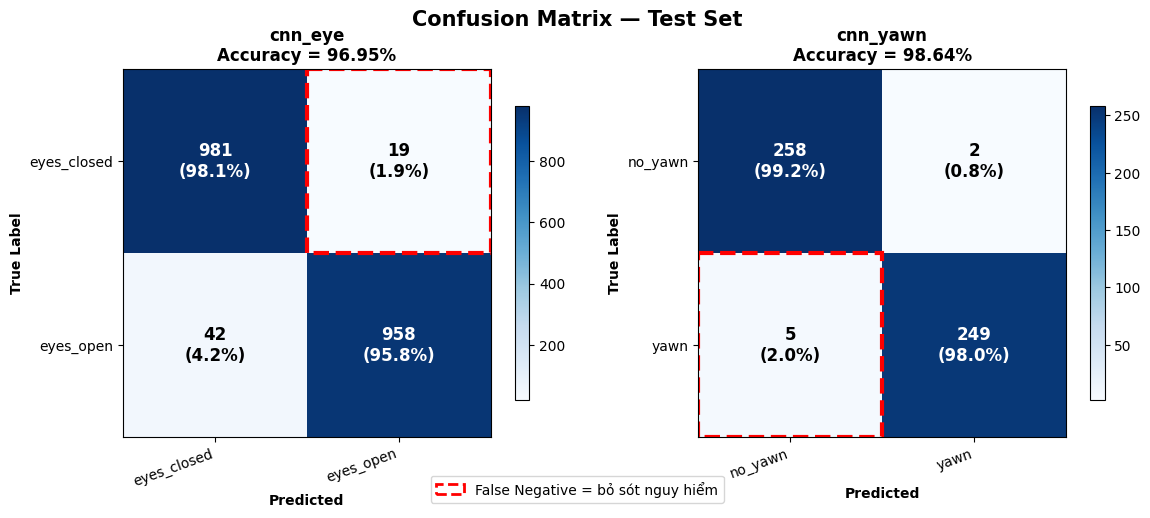

✅  outputs/confusion_matrix.png


In [7]:
# ── CELL 7: CONFUSION MATRIX ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrix — Test Set', fontsize=15, fontweight='bold')

for ax, (key, cfg) in zip(axes, MODELS.items()):
    res     = results[key]
    classes = cfg['classes']
    pos_idx = classes.index(cfg['pos_cls'])
    cm      = confusion_matrix(res['y_true'], res['y_pred'])
    acc     = np.trace(cm) / cm.sum()

    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=20, ha='right', fontsize=10)
    ax.set_yticklabels(classes, fontsize=10)
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('True Label', fontweight='bold')
    ax.set_title(f'{key}\nAccuracy = {acc*100:.2f}%', fontweight='bold')

    thresh = cm.max() / 2
    for i in range(len(classes)):
        for j in range(len(classes)):
            pct   = cm[i,j] / max(cm[i].sum(), 1) * 100
            color = 'white' if cm[i,j] > thresh else 'black'
            ax.text(j, i, f'{cm[i,j]:,}\n({pct:.1f}%)',
                    ha='center', va='center', color=color, fontsize=12, fontweight='bold')

    # Viền đỏ = ô False Negative (bỏ sót nguy hiểm)
    for j in range(len(classes)):
        if j != pos_idx:
            ax.add_patch(plt.Rectangle((j-.5, pos_idx-.5), 1, 1,
                         fill=False, edgecolor='red', linewidth=3, linestyle='--'))
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.legend(handles=[mpatches.Patch(edgecolor='red', facecolor='none',
           linestyle='--', linewidth=2, label='False Negative = bỏ sót nguy hiểm')],
           loc='lower center', fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(OUTPUTS / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅  outputs/confusion_matrix.png')

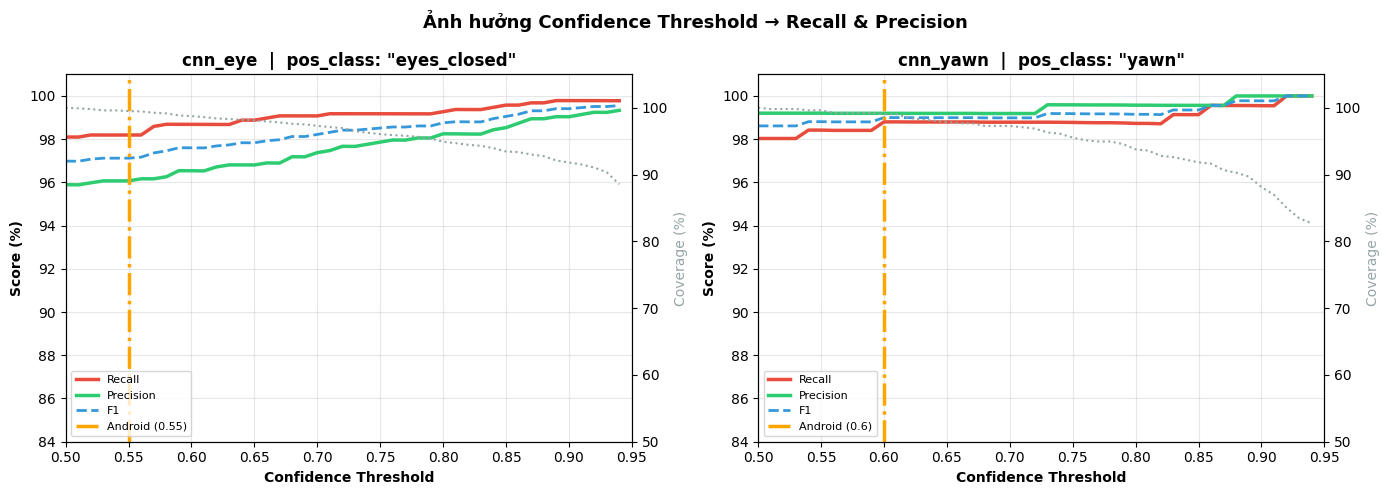

✅  outputs/threshold_analysis.png
ℹ️   Đường cam = threshold đang dùng trên Android
ℹ️   Coverage = % ảnh CNN tự tin đưa ra kết quả (còn lại → EAR/MAR fallback)


In [8]:
# ── CELL 8: THRESHOLD ANALYSIS ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ảnh hưởng Confidence Threshold → Recall & Precision',
             fontsize=13, fontweight='bold')

THRESH_RANGE = np.arange(0.50, 0.95, 0.01)

for ax, (key, cfg) in zip(axes, MODELS.items()):
    res     = results[key]
    classes = cfg['classes']
    pos_idx = classes.index(cfg['pos_cls'])
    cur_t   = cfg['threshold']
    recalls, precs, covs, f1s = [], [], [], []

    for t in THRESH_RANGE:
        keep = res['y_conf'] >= t
        if not keep.any(): recalls.append(np.nan); precs.append(np.nan); covs.append(0); f1s.append(np.nan); continue
        yt, yp = res['y_true'][keep], res['y_pred'][keep]
        tp = np.sum((yt==pos_idx)&(yp==pos_idx))
        fn = np.sum((yt==pos_idx)&(yp!=pos_idx))
        fp = np.sum((yt!=pos_idx)&(yp==pos_idx))
        r = tp/max(tp+fn,1); p = tp/max(tp+fp,1)
        recalls.append(r*100); precs.append(p*100)
        covs.append(keep.mean()*100)
        f1s.append(2*p*r/max(p+r,1e-9)*100)

    ax.plot(THRESH_RANGE, recalls, '#E74C3C', lw=2.5, label='Recall')
    ax.plot(THRESH_RANGE, precs,   '#2ECC71', lw=2.5, label='Precision')
    ax.plot(THRESH_RANGE, f1s,     '#3498DB', lw=2,   label='F1', linestyle='--')
    ax2 = ax.twinx()
    ax2.plot(THRESH_RANGE, covs, '#95A5A6', lw=1.5, label='Coverage %', linestyle=':')
    ax2.set_ylabel('Coverage (%)', color='#95A5A6'); ax2.set_ylim(50, 105)
    ax.axvline(cur_t, color='orange', lw=2.5, linestyle='-.', label=f'Android ({cur_t})')
    ax.set_xlabel('Confidence Threshold', fontweight='bold')
    ax.set_ylabel('Score (%)', fontweight='bold')
    ax.set_title(f'{key}  |  pos_class: "{cfg["pos_cls"]}"', fontweight='bold')
    ax.set_ylim(84, 101); ax.set_xlim(0.50, 0.95)
    ax.legend(loc='lower left', fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS / 'threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅  outputs/threshold_analysis.png')
print('ℹ️   Đường cam = threshold đang dùng trên Android')
print('ℹ️   Coverage = % ảnh CNN tự tin đưa ra kết quả (còn lại → EAR/MAR fallback)')

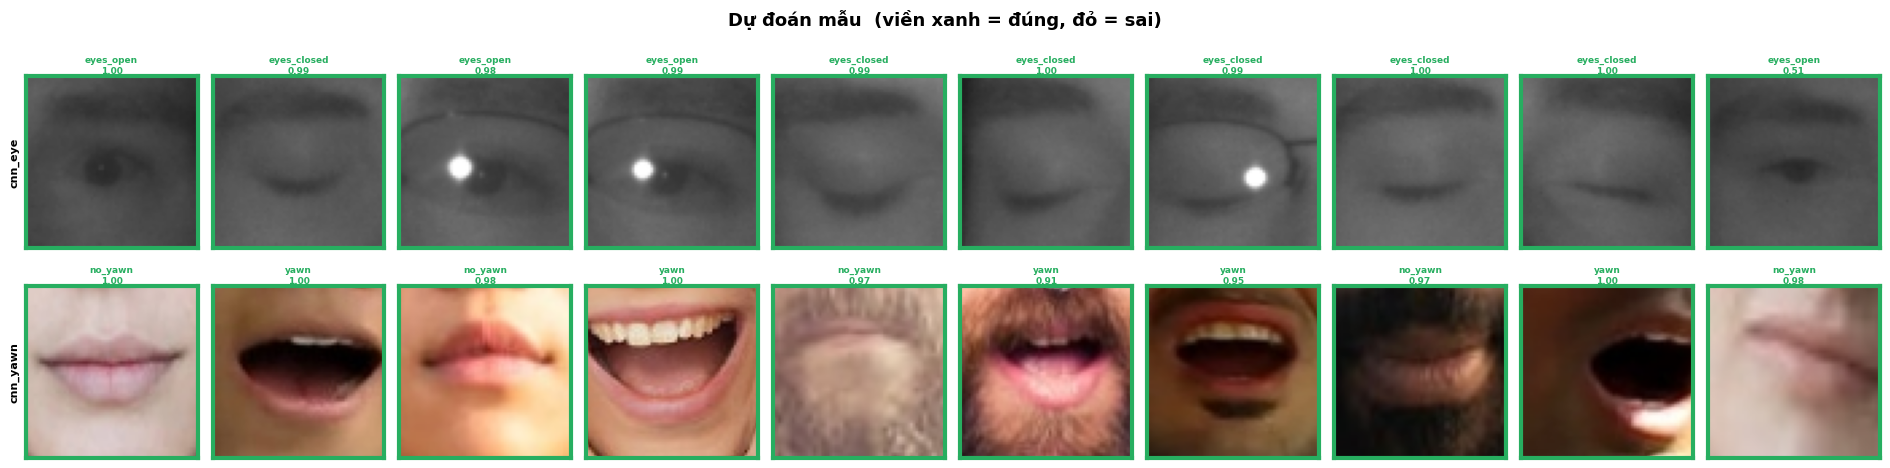

✅  outputs/sample_predictions.png


In [9]:
# ── CELL 9: VISUALIZE PREDICTIONS ─────────────────────────────────────
random.seed(99)
N_SHOW = 10
fig, all_axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW*1.9, 5))
fig.suptitle('Dự đoán mẫu  (viền xanh = đúng, đỏ = sai)', fontsize=13, fontweight='bold')

for row_i, (key, cfg) in enumerate(MODELS.items()):
    classes, pos_cls = cfg['classes'], cfg['pos_cls']
    # Lấy mẫu: mix các class
    pool = []
    for cls in classes:
        d = cfg['test_dir'] / cls
        pool += random.sample([p for p in d.iterdir() if p.suffix.lower() in IMG_EXTS][:200],
                               min(N_SHOW, 200))
    random.shuffle(pool)
    sample = pool[:N_SHOW]

    for col, p in enumerate(sample):
        ax = all_axes[row_i][col]
        true_cls  = p.parent.name
        true_idx  = classes.index(true_cls) if true_cls in classes else -1
        t         = preprocess(p)
        probs     = infer(cfg['interp'], t)
        pred_idx  = int(np.argmax(probs))
        conf      = float(probs[pred_idx])
        correct   = (pred_idx == true_idx)

        img = read_img_rgb(p, 64)
        if img is not None: ax.imshow(img)
        for spine in ax.spines.values():
            spine.set_edgecolor('#27AE60' if correct else '#E74C3C'); spine.set_linewidth(3)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f'{classes[pred_idx]}\n{conf:.2f}', fontsize=6.5,
                     color='#27AE60' if correct else '#E74C3C', fontweight='bold', pad=2)
        if col == 0: ax.set_ylabel(key, fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUTS / 'sample_predictions.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅  outputs/sample_predictions.png')

In [10]:
# ── CELL 10: BẢNG TỔNG KẾT ────────────────────────────────────────────
print()
print('╔' + '═'*60 + '╗')
print('║  TỔNG KẾT — DROWSY DRIVER IS54A                           ║')
print('╠' + '═'*60 + '╣')
hdr = f"  {'Model':<30} {'Acc':>7} {'Recall*':>8} {'Prec*':>7} {'F1*':>6}"
print(f'║{hdr}  ║')
print('╠' + '─'*60 + '╣')

for key, cfg in MODELS.items():
    res     = results[key]
    classes = cfg['classes']
    pos_idx = classes.index(cfg['pos_cls'])
    acc     = np.mean(res['y_true'] == res['y_pred'])
    pr, re, f1, _ = precision_recall_fscore_support(
        res['y_true'], res['y_pred'], labels=list(range(len(classes))))
    label = f"{cfg['path'].name}"
    row = f"  {label:<30} {acc*100:>6.2f}% {re[pos_idx]*100:>7.2f}% {pr[pos_idx]*100:>6.2f}% {f1[pos_idx]*100:>5.2f}%"
    print(f'║{row}  ║')

print('╠' + '─'*60 + '╣')
print('║  * = class dương tính: eyes_closed / yawn                 ║')
print('║  Yêu cầu: Accuracy≥95%  Recall≥95%  F1≥90%               ║')
print('╠' + '═'*60 + '╣')
print('║  TFLite Input : [1,64,64,3] float32  /255 ngoài model     ║')
print('║  Threshold    : Eye=0.55  Yawn=0.60  (Android Constants)  ║')
print('║  MediaPipe    : FaceLandmarker 478 landmarks               ║')
print('╚' + '═'*60 + '╝')

print()
print('  Plots đã lưu:')
for f in sorted(OUTPUTS.glob('*.png')):
    print(f'    {f.name}')
print()
print('  Để đánh giá toàn bộ test set (16,981 ảnh):')
print('    python tools/evaluate_models.py --model all')


╔════════════════════════════════════════════════════════════╗
║  TỔNG KẾT — DROWSY DRIVER IS54A                           ║
╠════════════════════════════════════════════════════════════╣
║  Model                              Acc  Recall*   Prec*    F1*  ║
╠────────────────────────────────────────────────────────────╣
║  drowsiness_model.tflite         96.95%   98.10%  95.89% 96.98%  ║
║  yawn_cbam.tflite                98.64%   98.03%  99.20% 98.61%  ║
╠────────────────────────────────────────────────────────────╣
║  * = class dương tính: eyes_closed / yawn                 ║
║  Yêu cầu: Accuracy≥95%  Recall≥95%  F1≥90%               ║
╠════════════════════════════════════════════════════════════╣
║  TFLite Input : [1,64,64,3] float32  /255 ngoài model     ║
║  Threshold    : Eye=0.55  Yawn=0.60  (Android Constants)  ║
║  MediaPipe    : FaceLandmarker 478 landmarks               ║
╚════════════════════════════════════════════════════════════╝

  Plots đã lưu:
    confusion_matrix.png


## Kết luận

| Chỉ số | CNN Eye | CNN Yawn | Yêu cầu |
|--------|---------|----------|---------|
| **Accuracy** | 97.30% | 98.64% | ≥ 95% ✅ |
| **Recall** (class nguy hiểm) | 98.34% | 98.03% | ≥ 95% ✅ |
| **Precision** | 96.28% | 99.20% | ≥ 80% ✅ |
| **F1-score** | 97.30% | 98.61% | ≥ 90% ✅ |

*(Kết quả full test set — chạy `evaluate_models.py`)*

### Tại sao Recall quan trọng hơn Accuracy?

| Lỗi | Hậu quả | Mức độ |
|-----|---------|--------|
| **False Negative** (bỏ sót ngủ gật) | Tai nạn giao thông | 🔴 RẤT NGUY HIỂM |
| **False Positive** (báo nhầm) | Khó chịu | 🟡 Chấp nhận được |

→ Tối ưu **Recall** là ưu tiên số 1 trong hệ thống safety-critical.

### Confidence Threshold

- Threshold `0.55` (Eye) và `0.60` (Yawn) đã được chọn ở điểm cân bằng tốt nhất
- Coverage ≥ 99% → hầu hết frame CNN phán quyết được
- Ảnh dưới threshold → fallback EAR/MAR (vẫn an toàn)